### Autocorrelation function and entropy of double pendulum

Given many double pendulums with different angle configurations, we wanna compute their first null lag (autocorrelation = 0), their permutation entropy and their sample entropy

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # Solves the system of differential equations
from joblib import Parallel, delayed # Multiprocessing
from numba import njit # Optimization C-speed
from scipy.signal import correlate # Correlation function by SciPy
from antropy import perm_entropy, sample_entropy # Entropy functions by Raphael Vellet (thank you!! https://raphaelvallat.com/antropy/)

In [2]:
def unbiased_autocorr_signal(x): # Compute autocorrelation of a given 1D array (unbiased version: no artificial decay)

    raw_corr = correlate(x, x, mode = 'full', method = 'fft') # FFT correlation x vs x
    corr_positive = raw_corr[len(raw_corr) // 2:] # Keep only the first half
    overlap_counts = np.arange(len(x), 0, -1)
    unbiased_corr = corr_positive / overlap_counts; unbiased_corr /= unbiased_corr[0]; unbiased_corr = unbiased_corr[:len(unbiased_corr) // 2 + 1] # Unbiased + Normalized + Half split

    return unbiased_corr

In [3]:
@njit(fastmath = True, cache = True) # Double Pendulum system for solve_ivp()
def double_pendulum_deriv(t, y): # System. m1 = m2 = l1 = l2 = 1.0 for simplicity

    theta, alpha, v_theta, v_alpha = y # order: theta, alpha, velocity theta, velocity alpha
    delta = theta - alpha
    sin_delta = np.sin(delta)
    cos_delta = np.cos(delta)
    sin_theta = np.sin(theta)
    sin_alpha = np.sin(alpha)
    den = 2.0 - cos_delta * cos_delta
    v_theta2 = v_theta ** 2
    v_alpha2 = v_alpha ** 2

    term1 = - sin_delta * (v_theta2 * cos_delta + v_alpha2)
    term2 = - 9.81 * (2.0 * sin_theta - sin_alpha * cos_delta)
    a_theta = (term1 + term2) / den # Theta acceleration

    term3 = sin_delta * (2.0 * v_theta2 + v_alpha2 * cos_delta)
    term4 = 9.81 * (2.0 * sin_theta * cos_delta - 2.0 * sin_alpha)
    a_alpha = (term3 + term4) / den # Alpha acceleration

    return [v_theta, v_alpha, a_theta, a_alpha] # order: velocity theta, velocity alpha, acceleration theta, acceleration alpha

In [4]:
def simulate_one(theta0, alpha0): # Executes one simulation

    y0 = [theta0, alpha0, 0.0, 0.0] # No initial velocities are considered

    sol = solve_ivp(
        fun = double_pendulum_deriv, # Double pendulum system
        t_span = (0.0, 60.0), # 1 minute of simulation fixed
        t_eval = np.arange(0.0, 60.0, 1e-02), # Solution evaluated on a uniform grid
        y0 = y0, # Initial conditions
        method = 'RK45', # Runge-Kutta 45
        atol = 1e-09, # Absolute tolerance
        rtol = 1e-06, # Relative tolerance
        max_step = 1e-02, # Maximum step allowed: 0.01
        dense_output = False # No dense output required
    )

    criterion = sol.y[2] - sol.y[3] # relative angular velocities chosen

    corr = unbiased_autocorr_signal(criterion) # Autocorrelation of the relative angular velocities
    corr_metric = np.argmax(corr < 0.0) # Returns the first lag where the autocorrelation function becomes zero

    perm_entropy_metric = perm_entropy(criterion, normalize = True) # Permutation entropy of relative angular velocity
    sample_entropy_metric = sample_entropy(criterion) # Sample entropy of relative angular velocity

    return [corr_metric, perm_entropy_metric, sample_entropy_metric]

In [5]:
N = 100 # Total number of subdivisions
min_angle0, max_angle0 = 15.0, 75.0 # [Degrees] min/max initial angles

In [6]:
initial_array = np.radians(np.linspace(min_angle0, max_angle0, N)) # Array of initial conditions
pairs = [(th, al) for th in initial_array for al in initial_array] # All possible initial possibilities

results = Parallel(n_jobs = -1, backend = 'loky')(delayed(simulate_one)(th, al) for th, al in pairs) # Computing the simulations in parallel

results_array = np.array(results) # shape (N, 3)

corr_metric_array = results_array[:, 0].reshape(N, N).T # Correlation metric array
perm_metric_array = results_array[:, 1].reshape(N, N).T # Permutation entropy metric array
sample_metric_array = results_array[:, 2].reshape(N, N).T # Sample entropy metric array

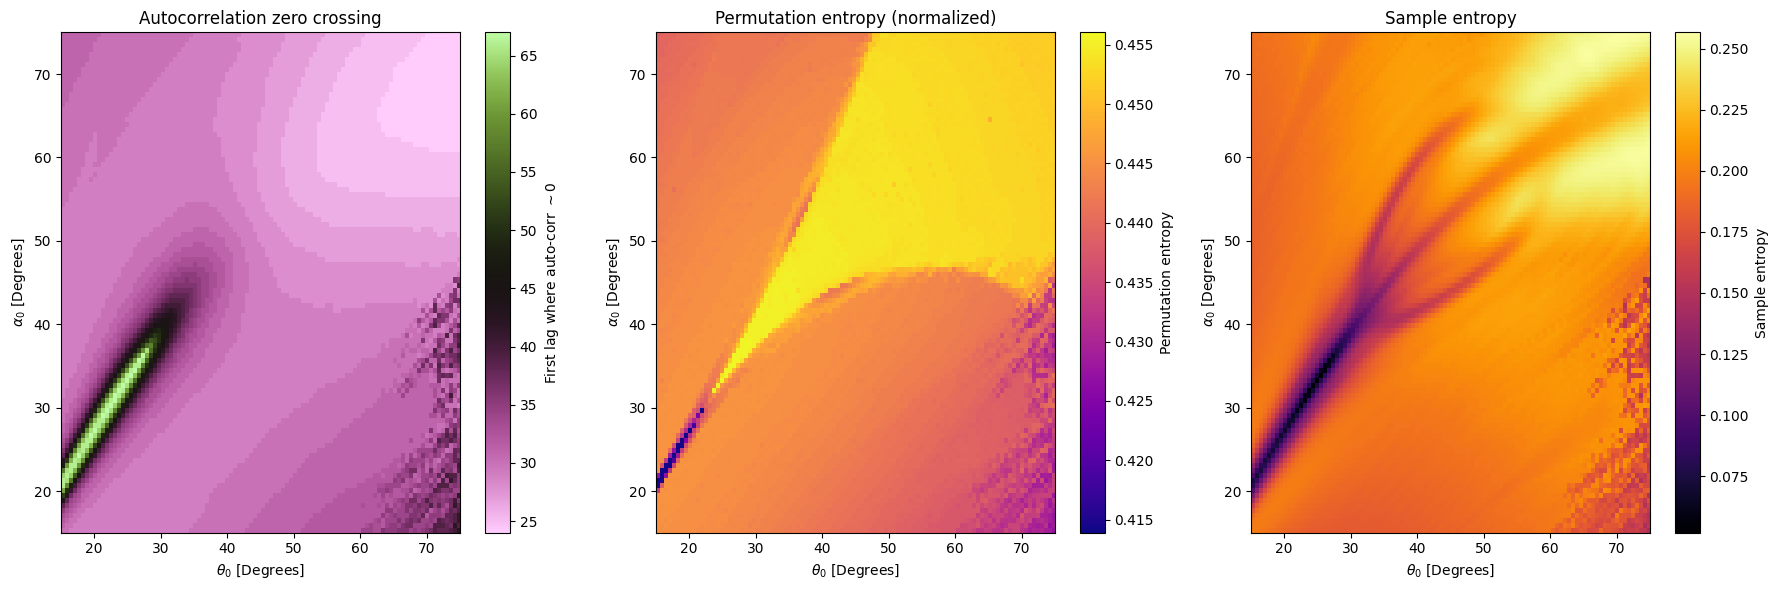

In [7]:
# Plot section
fig, axes = plt.subplots(1, 3, figsize = (18, 6))

# Plot 1: Autocorrelation zero‑crossing lag
im1 = axes[0].imshow(corr_metric_array, extent = [min_angle0, max_angle0, min_angle0, max_angle0], origin = 'lower', aspect = 'auto', cmap = 'vanimo')
axes[0].set_title(r'Autocorrelation zero crossing')
axes[0].set_xlabel(r'$\theta_{0}$ [Degrees]')
axes[0].set_ylabel(r'$\alpha_{0}$ [Degrees]')
fig.colorbar(im1, ax = axes[0], label = r'First lag where auto‑corr $\sim 0$')

# Plot 2: Permutation entropy (normalized)
im2 = axes[1].imshow(perm_metric_array, extent = [min_angle0, max_angle0, min_angle0, max_angle0], origin = 'lower', aspect = 'auto', cmap = 'plasma')
axes[1].set_title('Permutation entropy (normalized)')
axes[1].set_xlabel(r'$\theta_{0}$ [Degrees]')
axes[1].set_ylabel(r'$\alpha_{0}$ [Degrees]')
fig.colorbar(im2, ax = axes[1], label = 'Permutation entropy')

# Plot 3: Sample entropy
im3 = axes[2].imshow(sample_metric_array, extent = [min_angle0, max_angle0, min_angle0, max_angle0], origin = 'lower', aspect = 'auto', cmap = 'inferno')
axes[2].set_title('Sample entropy')
axes[2].set_xlabel(r'$\theta_{0}$ [Degrees]')
axes[2].set_ylabel(r'$\alpha_{0}$ [Degrees]')
fig.colorbar(im3, ax = axes[2], label = 'Sample entropy')

plt.tight_layout()
plt.show()